In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("ecommerce_dataset.csv")

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Display dataset info & preview
print("Dataset Overview:")
print(df.info())
df.head()


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       200 non-null    int64         
 1   Order_Date     200 non-null    datetime64[ns]
 2   City           200 non-null    object        
 3   Category       200 non-null    object        
 4   Product        200 non-null    object        
 5   Quantity       200 non-null    int64         
 6   Unit_Price     200 non-null    int64         
 7   Discount       200 non-null    int64         
 8   Sales          200 non-null    float64       
 9   Cost           200 non-null    float64       
 10  Profit         200 non-null    float64       
 11  Payment_Mode   200 non-null    object        
 12  Rating         200 non-null    int64         
 13  Delivery_Days  200 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(6), object(4)
me

,Order_ID,Order_Date,City,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Mode,Rating,Delivery_Days
0,1001,2025-01-01,Chennai,Furniture,Sofa,4,17396,0,69584.00,46310.58,23273.42,Card,5,5
1,1002,2025-01-02,Pune,Grocery,Snacks,3,46675,0,140025.00,92774.12,47250.88,Cash,5,5
2,1003,2025-01-03,Hyderabad,Electronics,Headphones,1,8305,25,6228.75,3627.01,2601.74,Net Banking,5,4
3,1004,2025-01-04,Hyderabad,Furniture,Chair,4,5737,0,22948.00,16485.86,6462.14,Net Banking,4,6
4,1005,2025-01-05,Bengaluru,Furniture,Bed,6,20556,20,98668.80,78019.85,20648.95,UPI,5,3


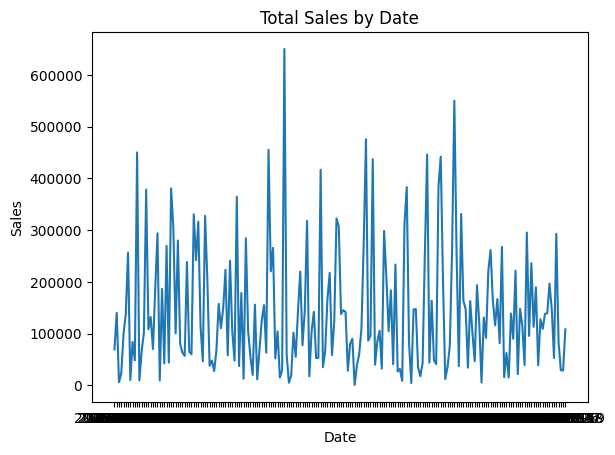

In [ ]:
sales_date = df.groupby("Order_Date")["Sales"].sum()
plt.plot(sales_date.index.astype(str), sales_date.values)
plt.title("Total Sales by Date")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

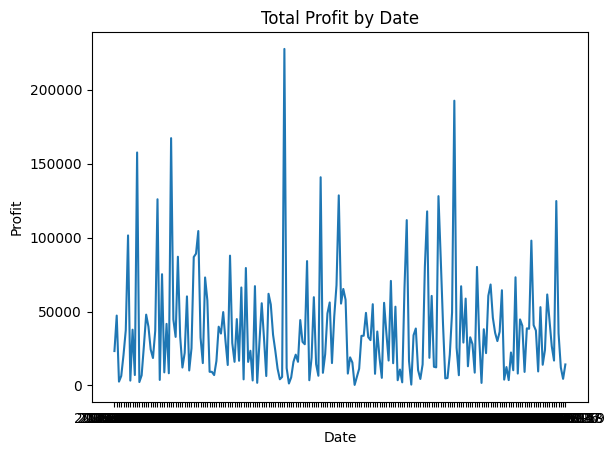

In [25]:
profit_date = df.groupby("Order_Date")["Profit"].sum()
plt.plot(profit_date.index.astype(str), profit_date.values)
plt.title("Total Profit by Date")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.show()

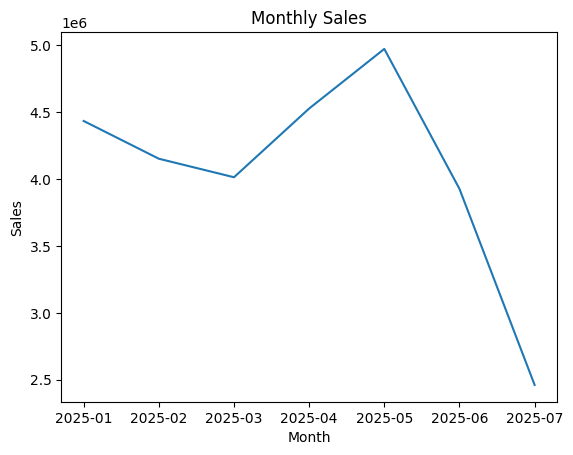

Highest Sales Month: 2025-05


In [26]:
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"].sum()
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

print("Highest Sales Month:", str(monthly_sales.idxmax()))

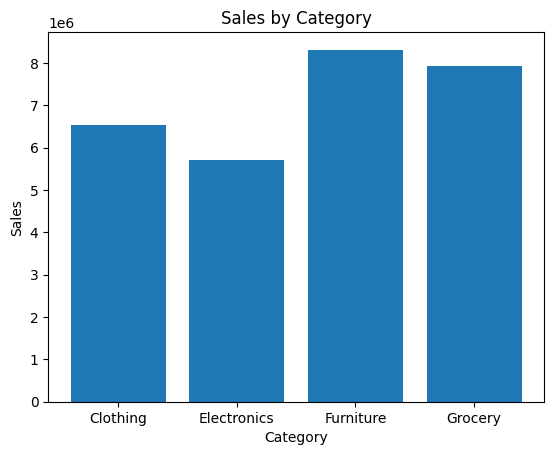

In [9]:
sales_cat = df.groupby("Category")["Sales"].sum()
plt.bar(sales_cat.index, sales_cat.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()


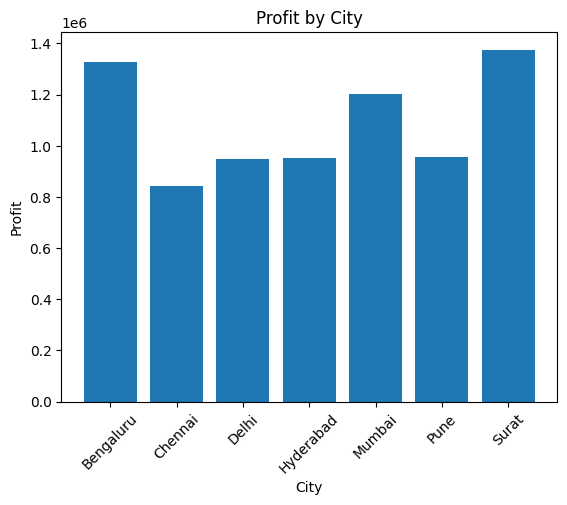

In [10]:
profit_city = df.groupby("City")["Profit"].sum()
plt.bar(profit_city.index, profit_city.values)
plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()


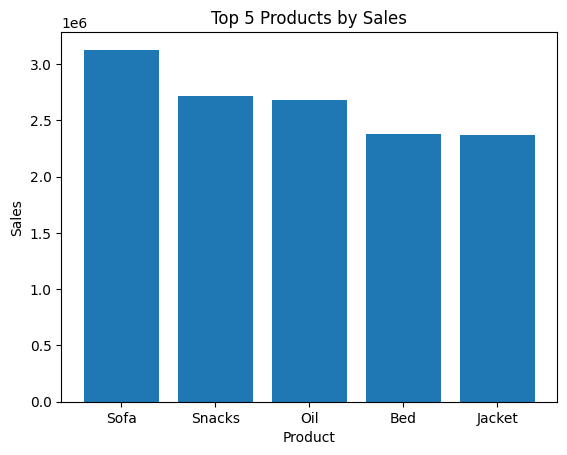

In [11]:
top5 = df.groupby("Product")["Sales"].sum().nlargest(5)
plt.bar(top5.index, top5.values)
plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()


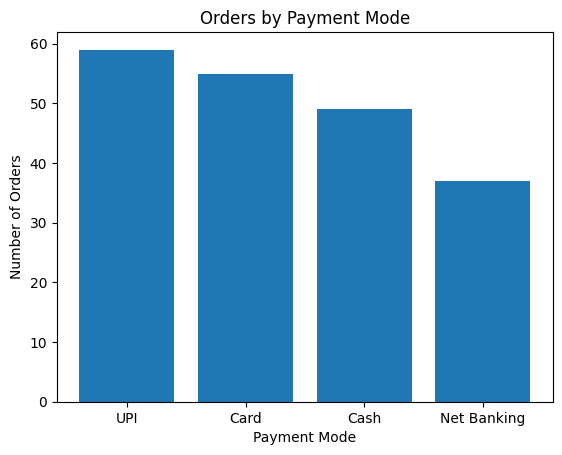

In [12]:
payment_orders = df["Payment_Mode"].value_counts()
plt.bar(payment_orders.index, payment_orders.values)
plt.title("Orders by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Orders")
plt.show()


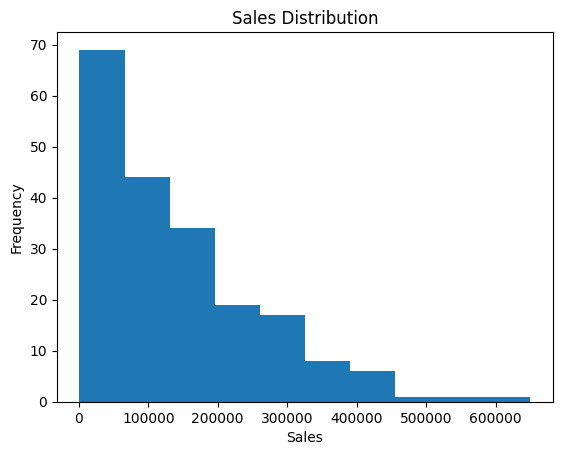

In [13]:
plt.hist(df["Sales"])
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


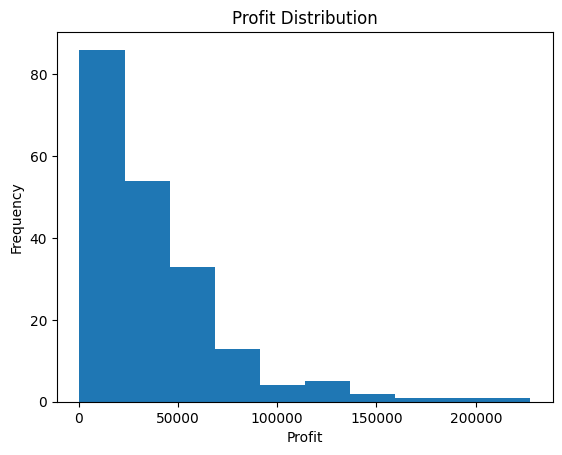

In [14]:
plt.hist(df["Profit"])
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()


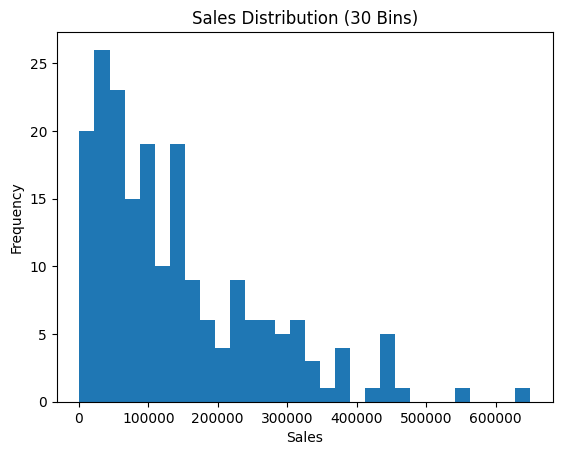

In [15]:
# Observe differences by changing bins count
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution (30 Bins)")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


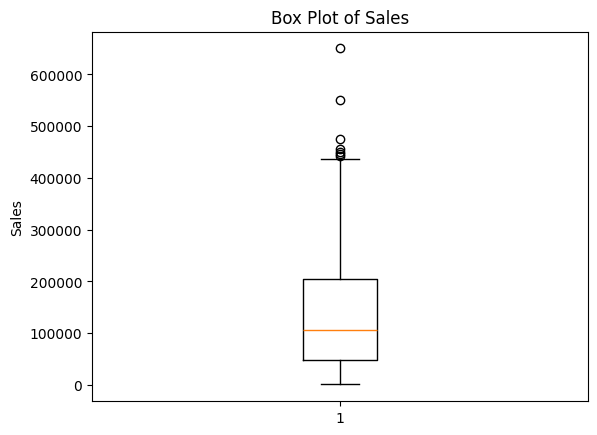

In [16]:
plt.boxplot(df["Sales"])
plt.title("Box Plot of Sales")
plt.ylabel("Sales")
plt.show()


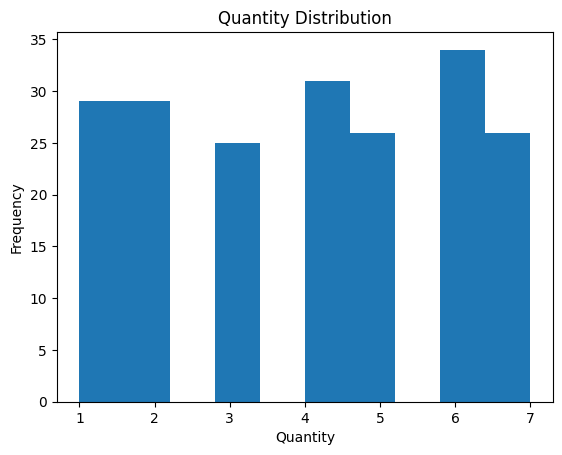

In [17]:
import matplotlib.pyplot as plt
plt.hist(df["Quantity"])
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

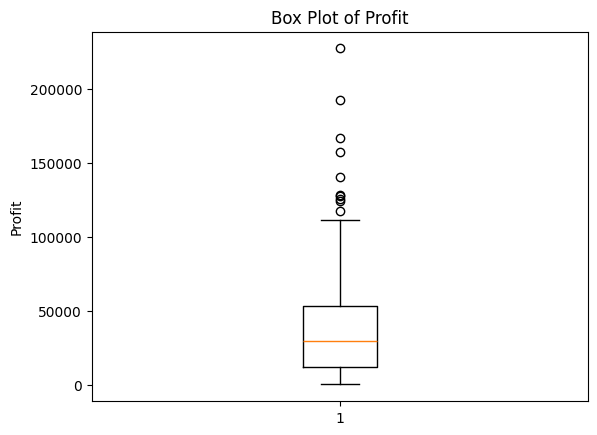

In [18]:
plt.boxplot(df["Profit"])
plt.title("Box Plot of Profit")
plt.ylabel("Profit")
plt.show()

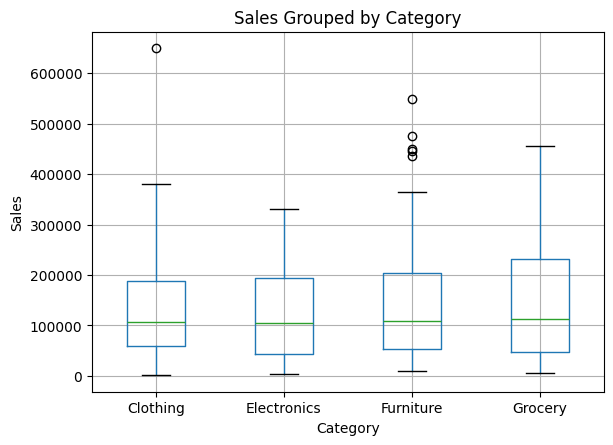

In [19]:
df.boxplot(column="Sales", by="Category")
plt.title("Sales Grouped by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [20]:
for col in ["Sales", "Profit"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"Possible Outliers in {col}:")
    print(outliers if not outliers.empty else "No outliers found\n")

Possible Outliers in Sales:
10     450000.00
68     455118.00
75     650000.00
111    475756.05
138    446012.00
144    442046.40
150    550000.00
Name: Sales, dtype: float64
Possible Outliers in Profit:
10     157500.00
19     125873.41
25     167188.31
75     227500.00
91     140756.68
99     128499.79
138    117680.21
143    127980.51
150    192500.00
195    124674.86
Name: Profit, dtype: float64


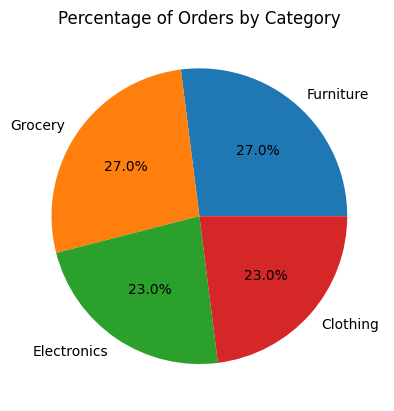

In [21]:
cat_counts = df["Category"].value_counts()
plt.pie(cat_counts, labels=cat_counts.index, autopct="%1.1f%%")
plt.title("Percentage of Orders by Category")
plt.show()

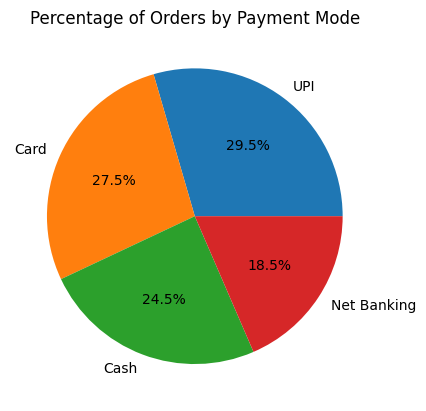

In [22]:
pm_counts = df["Payment_Mode"].value_counts()
plt.pie(pm_counts, labels=pm_counts.index, autopct="%1.1f%%")
plt.title("Percentage of Orders by Payment Mode")
plt.show()

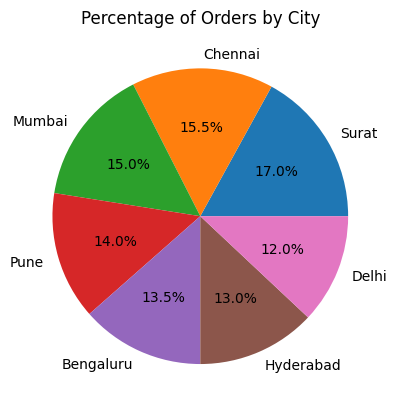

In [23]:
city_counts = df["City"].value_counts()
plt.pie(city_counts, labels=city_counts.index, autopct="%1.1f%%")
plt.title("Percentage of Orders by City")
plt.show()